<a href="https://colab.research.google.com/github/vedant1008-DE/Machine-Learning-Essentials-Lab-Sem-6/blob/main/Assignment_10_Gradient_Descent_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

Question 1 — Load Dataset

In [ ]:
data = fetch_california_housing()

X = data.data
y = data.target

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

# Sample records
pd.DataFrame(X, columns=data.feature_names).head()

Number of samples: 20640
Number of features: 8


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Question 2 — Split & Normalize

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Question 3 — Hypothesis & Cost Function

In [ ]:
# Add bias term
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Cost function
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    return (1/(2*m)) * np.sum((predictions - y)**2)

Question 4 — Batch Gradient Descent

In [ ]:
def batch_gd(X, y, lr=0.01, n_iter=100):
    m, n = X.shape
    theta = np.zeros(n)
    costs = []

    for _ in range(n_iter):
        gradients = (1/m) * X.T.dot(X.dot(theta) - y)
        theta -= lr * gradients
        costs.append(compute_cost(X, y, theta))

    return theta, costs

theta_bgd, cost_bgd = batch_gd(X_train_b, y_train)

Plot

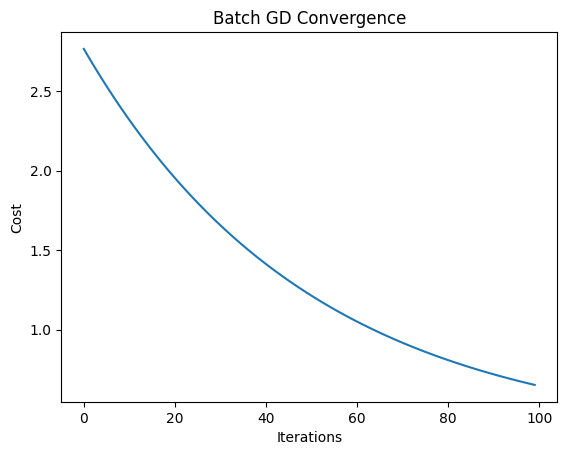

In [ ]:
plt.plot(cost_bgd)
plt.title("Batch GD Convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

Question 5 — Stochastic Gradient Descent

In [ ]:
def sgd(X, y, lr=0.01, n_iter=5):
    m, n = X.shape
    theta = np.zeros(n)
    costs = []

    for _ in range(n_iter):
        for i in range(m):
            xi = X[i:i+1]
            yi = y[i]
            gradients = xi.T.dot(xi.dot(theta) - yi)
            theta -= lr * gradients

        costs.append(compute_cost(X, y, theta))

    return theta, costs

theta_sgd, cost_sgd = sgd(X_train_b, y_train)

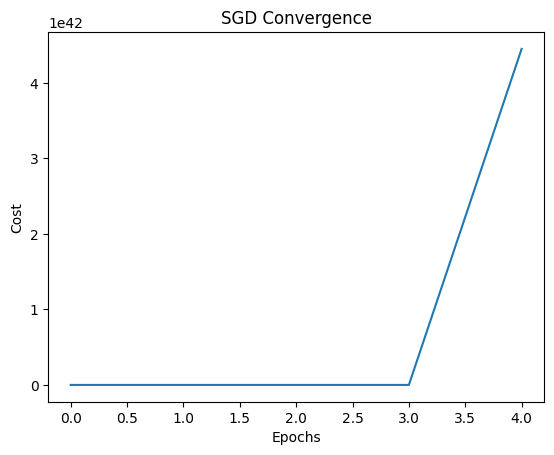

In [ ]:
plt.plot(cost_sgd)
plt.title("SGD Convergence")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

Question 6 — Mini-Batch Gradient Descent

In [ ]:
def mini_batch_gd(X, y, lr=0.01, n_iter=50, batch_size=32):
    m, n = X.shape
    theta = np.zeros(n)
    costs = []

    for _ in range(n_iter):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]

            gradients = (1/len(xi)) * xi.T.dot(xi.dot(theta) - yi)
            theta -= lr * gradients

        costs.append(compute_cost(X, y, theta))

    return theta, costs

theta_mbgd, cost_mbgd = mini_batch_gd(X_train_b, y_train)

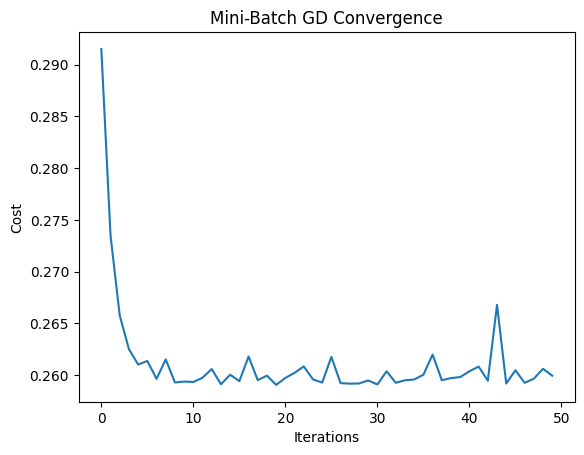

In [ ]:
plt.plot(cost_mbgd)
plt.title("Mini-Batch GD Convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

Question 7 — Compare Convergence Graphs

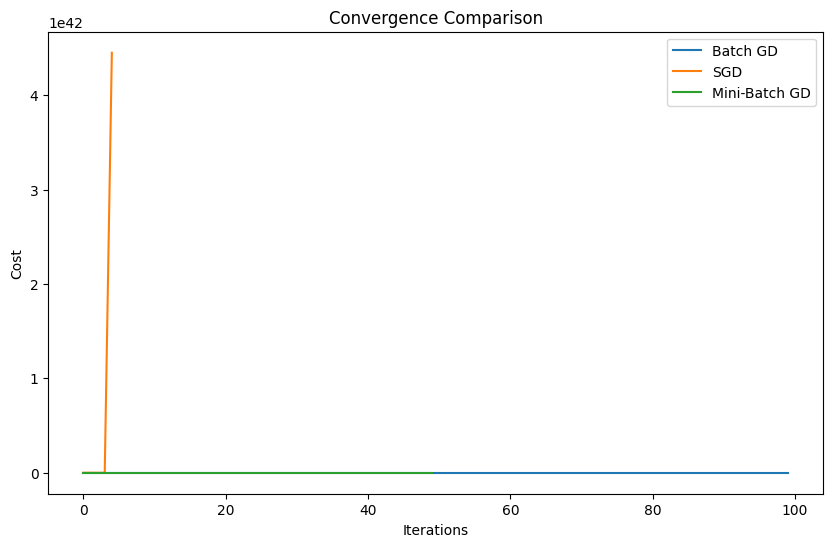

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(cost_bgd, label="Batch GD")
plt.plot(cost_sgd, label="SGD")
plt.plot(cost_mbgd, label="Mini-Batch GD")

plt.legend()
plt.title("Convergence Comparison")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

Question 7 — Compare Convergence Graphs

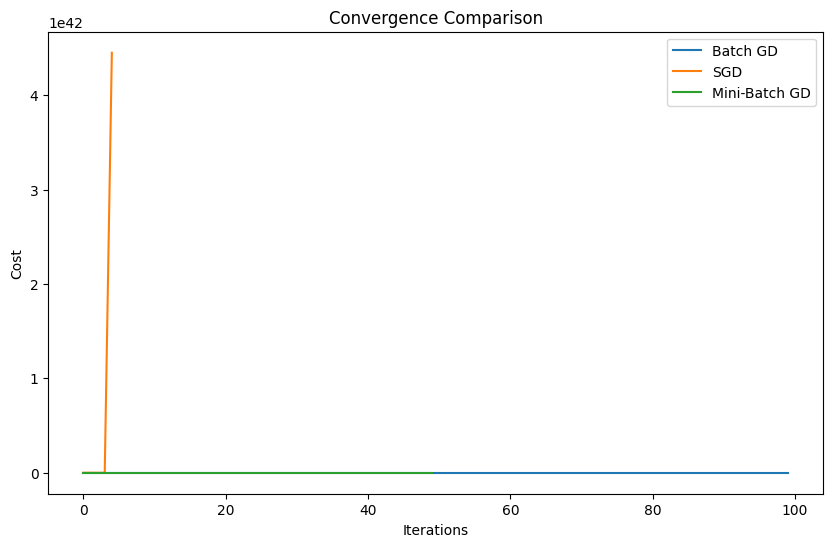

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(cost_bgd, label="Batch GD")
plt.plot(cost_sgd, label="SGD")
plt.plot(cost_mbgd, label="Mini-Batch GD")

plt.legend()
plt.title("Convergence Comparison")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [ ]:
print("BGD: Smooth but slow")
print("SGD: Fast but noisy")
print("Mini-Batch: Balanced approach")

BGD: Smooth but slow
SGD: Fast but noisy
Mini-Batch: Balanced approach


Question 8 — Evaluate Final Model

In [ ]:
def rmse(X, y, theta):
    preds = X.dot(theta)
    return np.sqrt(mean_squared_error(y, preds))

print("RMSE BGD:", rmse(X_test_b, y_test, theta_bgd))
print("RMSE SGD:", rmse(X_test_b, y_test, theta_sgd))
print("RMSE Mini-Batch:", rmse(X_test_b, y_test, theta_mbgd))

RMSE BGD: 1.1386783400021694
RMSE SGD: 4.4670699262125854e+20
RMSE Mini-Batch: 0.7392252696729944


Question 9 — Hyperparameters

In [ ]:
print("Learning Rate:")
print("- Too high → divergence")
print("- Too low → slow convergence\n")

print("Iterations:")
print("- Too few → underfitting")
print("- Too many → waste time\n")

print("Batch Size:")
print("- Small → noisy")
print("- Large → slow but stable")

Learning Rate:
- Too high → divergence
- Too low → slow convergence

Iterations:
- Too few → underfitting
- Too many → waste time

Batch Size:
- Small → noisy
- Large → slow but stable


Question 10 — Reflection

In [ ]:
print("Reflection:\n")

print("Use SGD when dataset is large and fast learning is needed")
print("Use Batch GD when dataset is small and stable convergence required")
print("Mini-Batch is preferred due to balance of speed and performance")

Reflection:

Use SGD when dataset is large and fast learning is needed
Use Batch GD when dataset is small and stable convergence required
Mini-Batch is preferred due to balance of speed and performance


Final Conclusion

In [ ]:
print("Conclusion:\n")

print("- Gradient Descent minimizes loss function")
print("- Different strategies affect speed and stability")
print("- Mini-Batch is most practical in real-world ML")

Conclusion:

- Gradient Descent minimizes loss function
- Different strategies affect speed and stability
- Mini-Batch is most practical in real-world ML
